# Final Project: Phishing Detection Using Machine Learning Techniques

Course: **Data Science in Cybersecurity**

This notebook is a clean critical reproduction project based on the selected paper:
**"Phishing Detection Using Machine Learning Techniques"** by Vahid Shahrivari, Mohammad Mahdi Darabi, and Mohammad Izadi.

The goal is not to copy the original repository as-is. The goal is to build a clear, reproducible university project that loads the paper's phishing dataset, inspects the data, performs EDA, trains machine-learning models, evaluates them with security-relevant metrics, and discusses reproducibility limitations.

Original GitHub repository:
https://github.com/fafal-abnir/phishing_detection

## 1. Setup and Imports

The project uses standard Python data-science libraries. `xgboost` is used if installed; otherwise the notebook automatically uses `GradientBoostingClassifier`.

All random operations use `random_state=42` for reproducibility.

In [1]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics import make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_PATH = Path("data") / "dataset.csv"
DATA_URL = "https://raw.githubusercontent.com/fafal-abnir/phishing_detection/master/dataset.csv"
TARGET_COLUMN = "Result"

## 2. Helper Functions

The following functions keep the notebook clean and avoid duplicated code. The workflow is separated into data loading, inspection, preprocessing, model training, evaluation, and plotting.

In [2]:
def load_data(data_path=DATA_PATH, data_url=DATA_URL):
    """Load the phishing dataset locally, or download it automatically in Google Colab."""
    data_path = Path(data_path)
    if not data_path.exists():
        print(f"Dataset not found at {data_path}. Downloading from the original GitHub repository...")
        data_path.parent.mkdir(parents=True, exist_ok=True)
        pd.read_csv(data_url).to_csv(data_path, index=False)
        print(f"Dataset saved to {data_path}")
    return pd.read_csv(data_path)


def inspect_data(dataframe, target_column=TARGET_COLUMN):
    """Inspect structure, quality issues, target distribution, and basic statistics."""
    print("Dataset shape:", dataframe.shape)
    print("\nColumn names:")
    print(dataframe.columns.tolist())
    print("\nData types:")
    print(dataframe.dtypes)
    print(f"\nTarget column: {target_column}")
    print("\nClass distribution:")
    print(dataframe[target_column].value_counts(dropna=False))
    print("\nClass distribution (%):")
    print((dataframe[target_column].value_counts(normalize=True) * 100).round(2))
    print("\nMissing values:")
    print(dataframe.isna().sum())
    print("\nDuplicate rows:", dataframe.duplicated().sum())
    single_value_columns = [
        column for column in dataframe.columns
        if dataframe[column].nunique(dropna=False) == 1
    ]
    print("\nSingle-value columns:", single_value_columns)
    print("\nBasic descriptive statistics:")
    display(dataframe.describe(include="all").T)
    return single_value_columns


def preprocess_data(dataframe, target_column=TARGET_COLUMN, remove_high_correlation=False, correlation_threshold=0.95):
    """Prepare features and target. Encode phishing as the positive class."""
    processed_dataframe = dataframe.copy()
    processed_dataframe = processed_dataframe.drop(columns=["index"], errors="ignore")

    features = processed_dataframe.drop(columns=[target_column])
    original_target = processed_dataframe[target_column]

    # In the original dataset: -1 = phishing, 1 = legitimate.
    # For cybersecurity metrics, phishing is encoded as the positive class.
    target = original_target.map({-1: 1, 1: 0})

    removed_features = []
    if remove_high_correlation:
        absolute_correlation = features.corr(method="spearman").abs()
        upper_triangle = absolute_correlation.where(
            np.triu(np.ones(absolute_correlation.shape), k=1).astype(bool)
        )
        removed_features = [
            column for column in upper_triangle.columns
            if any(upper_triangle[column] > correlation_threshold)
        ]
        features = features.drop(columns=removed_features)

    return features, target, removed_features


def train_models(random_state=RANDOM_STATE):
    """Create model definitions with scaling only where it is useful."""
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=random_state)),
        ]),
        "Decision Tree": DecisionTreeClassifier(random_state=random_state),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1,
            class_weight="balanced",
        ),
    }

    try:
        from xgboost import XGBClassifier

        models["XGBoost"] = XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=random_state,
            n_jobs=-1,
        )
    except Exception as error:
        print(f"XGBoost is not available ({error}). Using GradientBoostingClassifier instead.")
        models["Gradient Boosting"] = GradientBoostingClassifier(random_state=random_state)

    return models


def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Fit one model and calculate classification metrics."""
    fitted_model = clone(model)

    train_start_time = time.perf_counter()
    fitted_model.fit(X_train, y_train)
    train_time = time.perf_counter() - train_start_time

    test_start_time = time.perf_counter()
    y_predicted = fitted_model.predict(X_test)
    test_time = time.perf_counter() - test_start_time

    if hasattr(fitted_model, "predict_proba"):
        y_score = fitted_model.predict_proba(X_test)[:, 1]
    elif hasattr(fitted_model, "decision_function"):
        y_score = fitted_model.decision_function(X_test)
    else:
        y_score = y_predicted

    metrics = {
        "Accuracy": accuracy_score(y_test, y_predicted),
        "Precision": precision_score(y_test, y_predicted, zero_division=0),
        "Recall": recall_score(y_test, y_predicted, zero_division=0),
        "F1": f1_score(y_test, y_predicted, zero_division=0),
        "F2": fbeta_score(y_test, y_predicted, beta=2, zero_division=0),
        "MCC": matthews_corrcoef(y_test, y_predicted),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "PR-AUC / Average Precision": average_precision_score(y_test, y_score),
        "Train Time (s)": train_time,
        "Test Time (s)": test_time,
    }
    return fitted_model, metrics, y_predicted, y_score


def plot_confusion_matrix(y_true, y_predicted, title):
    """Plot a confusion matrix with phishing as the positive class."""
    matrix = confusion_matrix(y_true, y_predicted)
    display_object = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Legitimate", "Phishing"],
    )
    display_object.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.grid(False)
    plt.show()

## 3. Data Loading

The dataset file is stored locally in `data/dataset.csv` so the notebook can run from a fresh environment after installing dependencies.

In [3]:
phishing_data = load_data()
phishing_data.head()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


## 4. Data Inspection

This section checks the dataset shape, columns, data types, target column, missing values, duplicate rows, single-value columns, class distribution, and descriptive statistics.

In [4]:
single_value_columns = inspect_data(phishing_data)

Dataset shape: (11055, 32)

Column names:
['index', 'having_IPhaving_IP_Address', 'URLURL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']

Data types:
index                          int64
having_IPhaving_IP_Address     int64
URLURL_Length                  int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        in

,count,mean,std,min,25%,50%,75%,max
index,11055.0,5528.000000,3191.447947,1.0,2764.5,5528.0,8291.5,11055.0
having_IPhaving_IP_Address,11055.0,0.313795,0.949534,-1.0,-1.0,1.0,1.0,1.0
URLURL_Length,11055.0,-0.633198,0.766095,-1.0,-1.0,-1.0,-1.0,1.0
Shortining_Service,11055.0,0.738761,0.673998,-1.0,1.0,1.0,1.0,1.0
having_At_Symbol,11055.0,0.700588,0.713598,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.741474,0.671011,-1.0,1.0,1.0,1.0,1.0
Prefix_Suffix,11055.0,-0.734962,0.678139,-1.0,-1.0,-1.0,-1.0,1.0
having_Sub_Domain,11055.0,0.063953,0.817518,-1.0,-1.0,0.0,1.0,1.0
SSLfinal_State,11055.0,0.250927,0.911892,-1.0,-1.0,1.0,1.0,1.0
Domain_registeration_length,11055.0,-0.336771,0.941629,-1.0,-1.0,-1.0,1.0,1.0


## 5. Class Imbalance Analysis

In cybersecurity, class imbalance matters because phishing examples may be less common than legitimate examples in real traffic. In this dataset, the classes are reasonably balanced, but we still use stratification to preserve the phishing/legitimate ratio in train and test sets.

,Count,Percentage
Result,,
Legitimate,6157,55.69
Phishing,4898,44.31


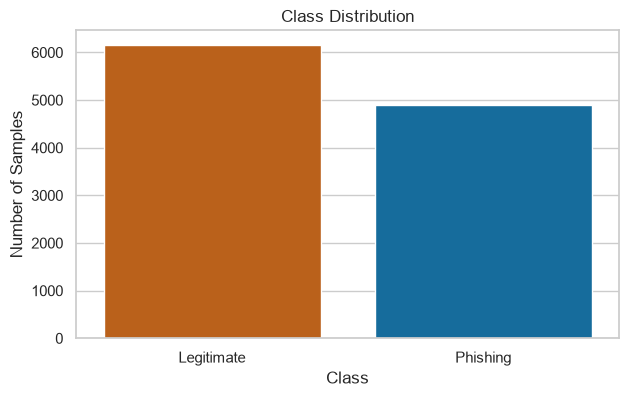

In [5]:
class_counts = phishing_data[TARGET_COLUMN].map({-1: "Phishing", 1: "Legitimate"}).value_counts()
class_percentages = phishing_data[TARGET_COLUMN].map({-1: "Phishing", 1: "Legitimate"}).value_counts(normalize=True) * 100

display(pd.DataFrame({"Count": class_counts, "Percentage": class_percentages.round(2)}))

plt.figure(figsize=(7, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=["#d55e00", "#0072b2"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

## 6. Feature Distributions

Most features are discrete indicators with values such as `-1`, `0`, and `1`. These values represent suspicious, neutral, or legitimate states depending on the feature definition.

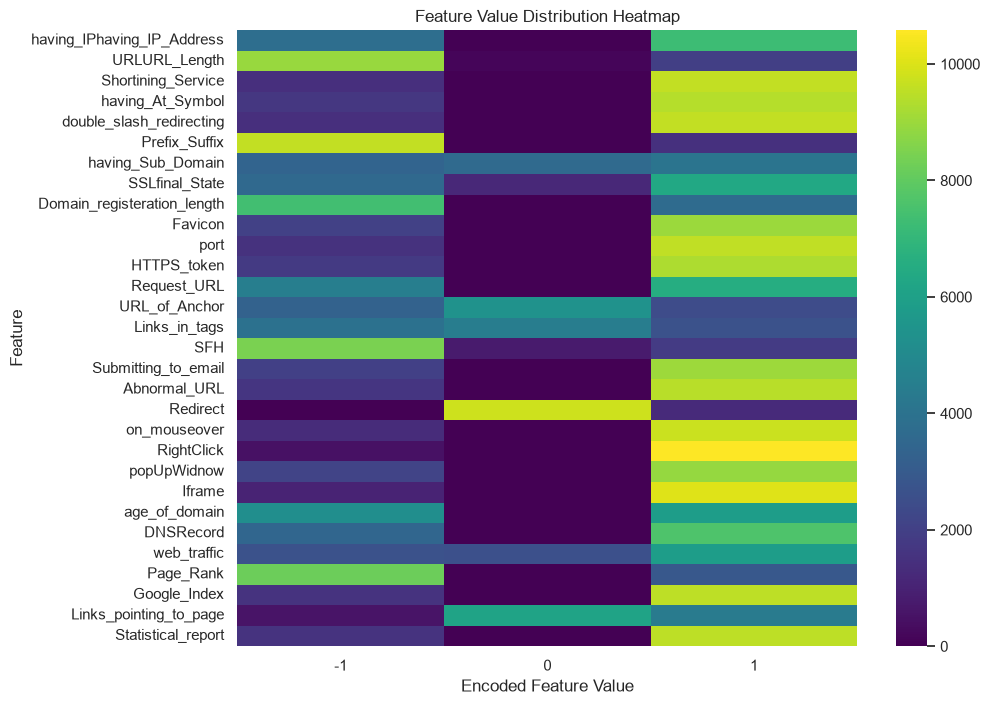

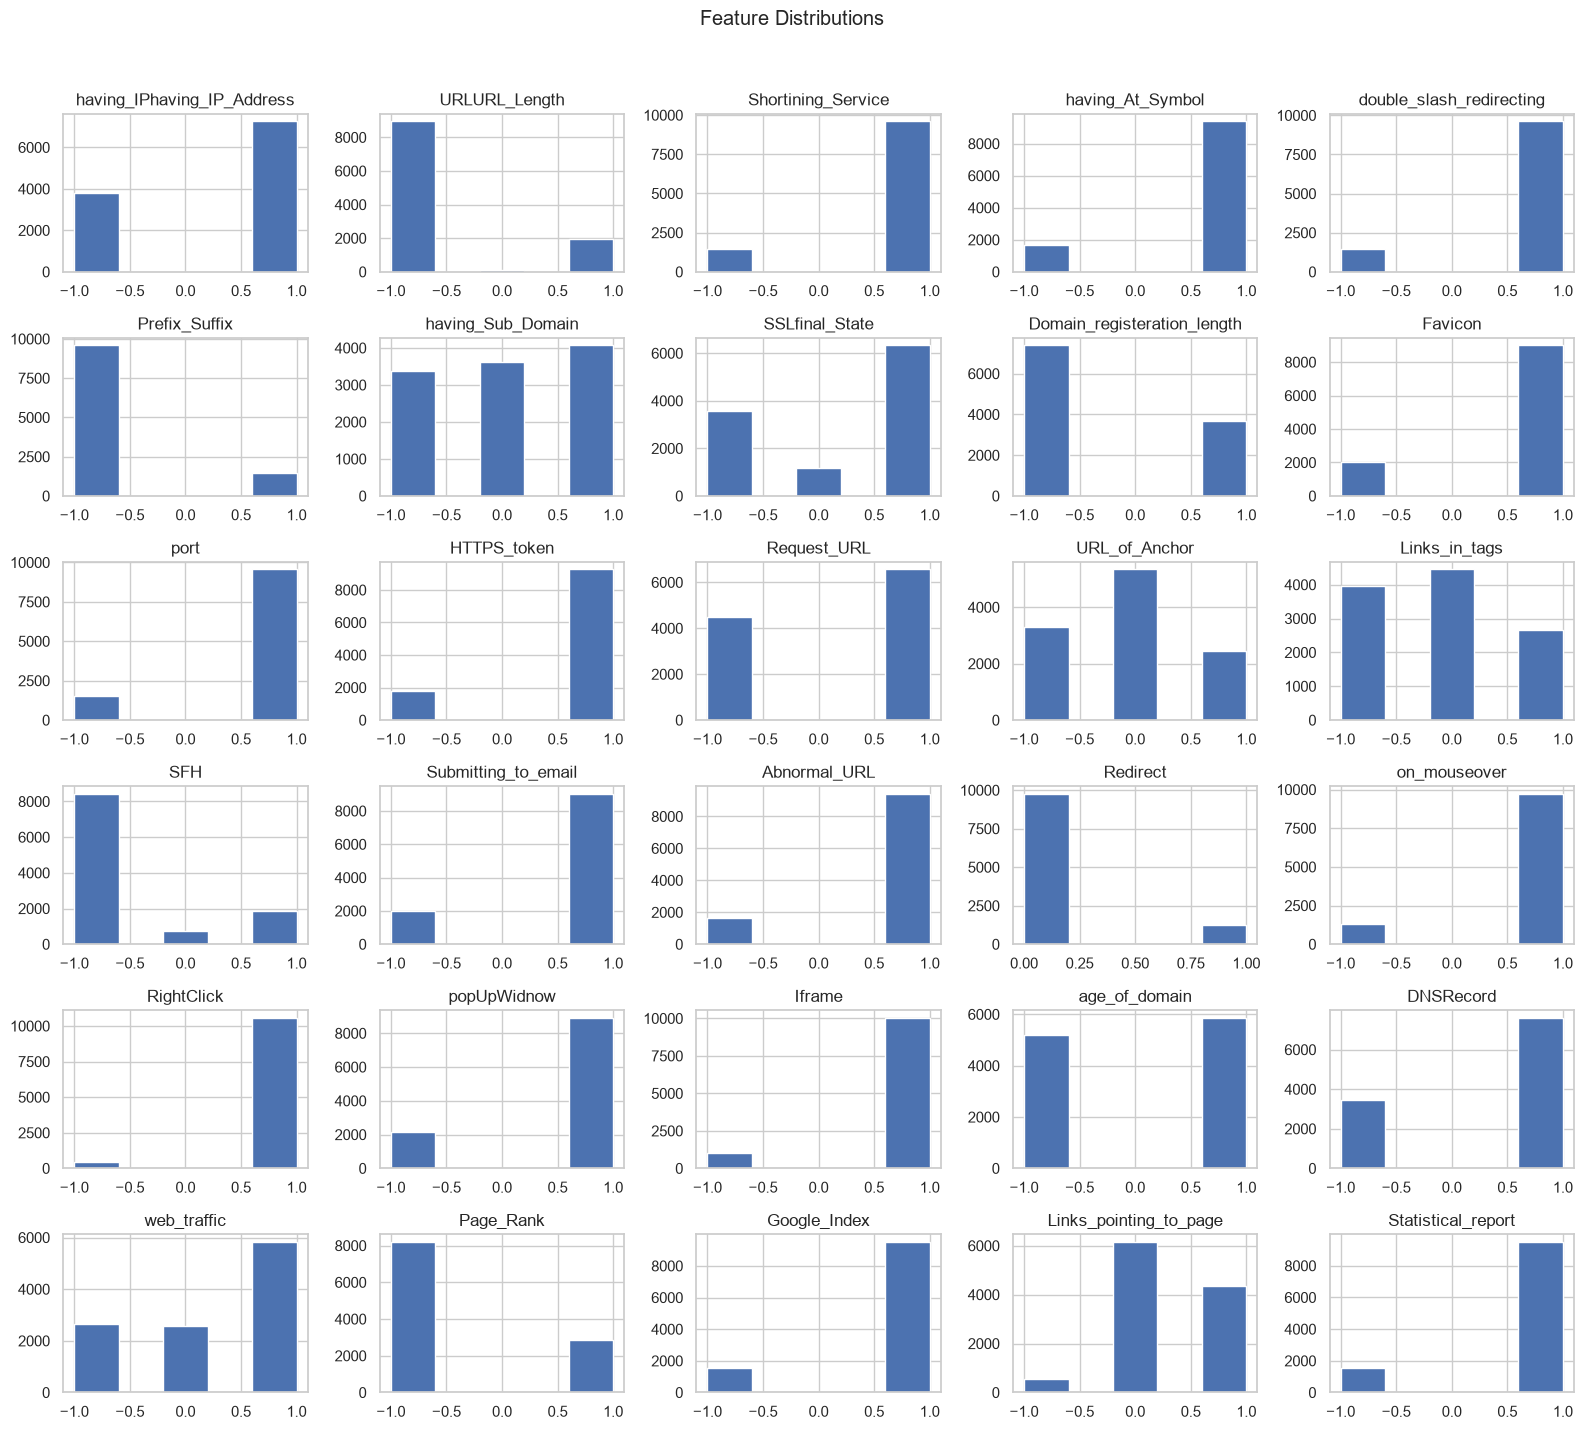

In [6]:
feature_data = phishing_data.drop(columns=["index", TARGET_COLUMN], errors="ignore")
feature_value_counts = feature_data.apply(lambda column: column.value_counts()).fillna(0).T

plt.figure(figsize=(10, 8))
sns.heatmap(feature_value_counts, cmap="viridis")
plt.title("Feature Value Distribution Heatmap")
plt.xlabel("Encoded Feature Value")
plt.ylabel("Feature")
plt.show()

feature_data.hist(figsize=(16, 14), bins=5)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

## 7. Outlier Analysis

Traditional numerical outliers are less meaningful here because the features are rule-based categorical/ordinal indicators, not continuous measurements. Instead, unusual samples are combinations of rare feature values. The code below identifies rare values and counts how many rare values each sample contains.

Features with values appearing in less than 1% of samples:


Series([], Name: rare_values, dtype: object)

,rare_feature_count
count,11055.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


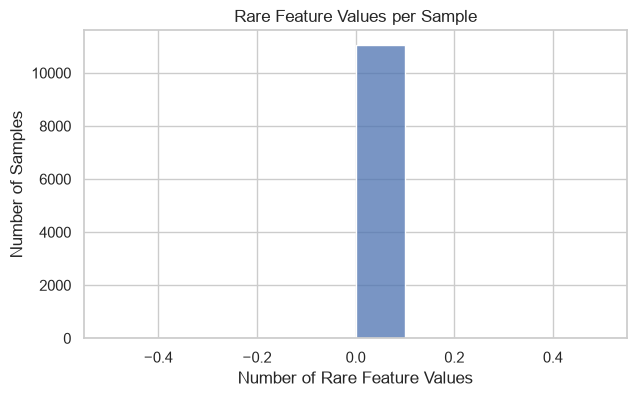

In [7]:
rare_value_summary = {}
for column in feature_data.columns:
    normalized_counts = feature_data[column].value_counts(normalize=True)
    rare_values = normalized_counts[normalized_counts < 0.01].index.tolist()
    if rare_values:
        rare_value_summary[column] = rare_values

print("Features with values appearing in less than 1% of samples:")
display(pd.Series(rare_value_summary, name="rare_values"))

rare_value_flags = pd.DataFrame(index=feature_data.index)
for column, rare_values in rare_value_summary.items():
    rare_value_flags[column] = feature_data[column].isin(rare_values)

rare_value_count_per_sample = rare_value_flags.sum(axis=1) if not rare_value_flags.empty else pd.Series(0, index=feature_data.index)
display(rare_value_count_per_sample.describe().to_frame("rare_feature_count"))

plt.figure(figsize=(7, 4))
sns.histplot(rare_value_count_per_sample, bins=10)
plt.title("Rare Feature Values per Sample")
plt.xlabel("Number of Rare Feature Values")
plt.ylabel("Number of Samples")
plt.show()

## 8. Correlation Analysis

Three common correlation methods are:

- **Pearson correlation**: best for continuous numerical variables and linear relationships.
- **Spearman correlation**: rank-based, suitable for ordinal variables and monotonic relationships.
- **Kendall correlation**: rank-based and robust, often useful for smaller datasets or many tied ranks, but slower.

This dataset uses ordinal/categorical encoded feature values (`-1`, `0`, `1`). Therefore, **Spearman correlation** is the most appropriate primary method. Pearson is less suitable because the encoded distances are not truly continuous measurements. Kendall could also be defensible, but Spearman is easier to interpret and efficient for this dataset size.

,Spearman correlation with original Result
SSLfinal_State,0.735814
URL_of_Anchor,0.701207
web_traffic,0.365118
Prefix_Suffix,0.348606
having_Sub_Domain,0.304692
Request_URL,0.253372
Links_in_tags,0.250711
Domain_registeration_length,-0.225789
SFH,0.219190
Google_Index,0.128950


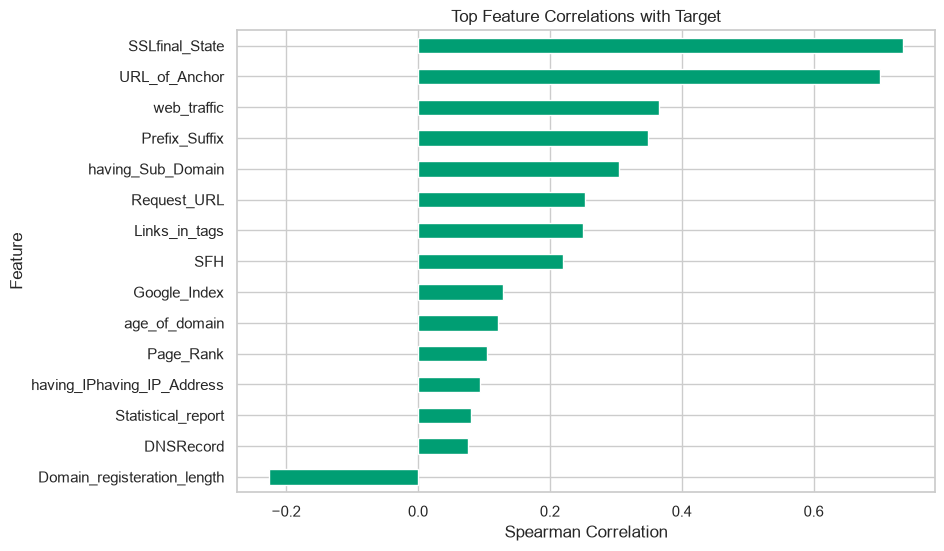

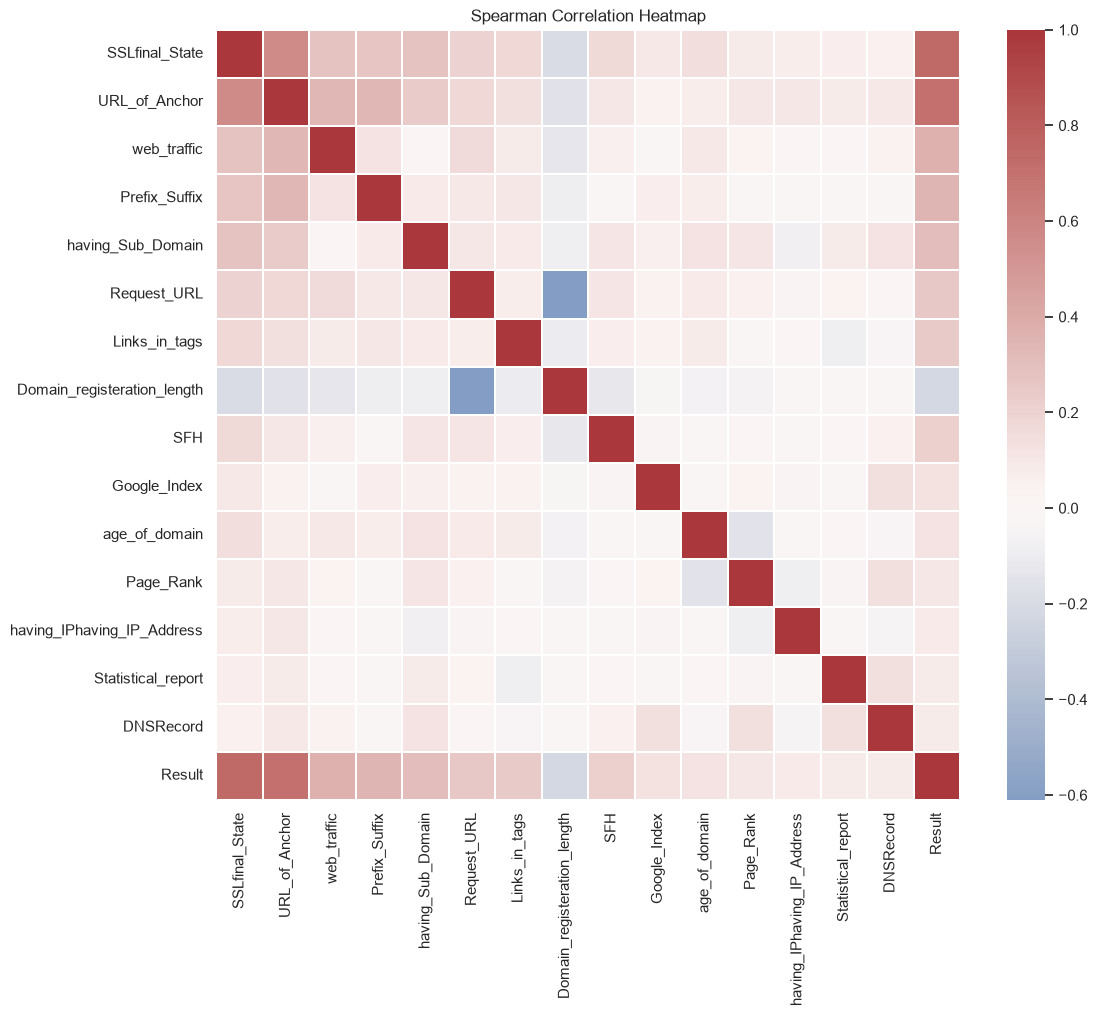

In [8]:
analysis_data = phishing_data.drop(columns=["index"], errors="ignore")
spearman_correlation = analysis_data.corr(method="spearman")
target_correlation = spearman_correlation[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(
    key=lambda values: values.abs(),
    ascending=False,
)

display(target_correlation.to_frame("Spearman correlation with original Result").head(15))

plt.figure(figsize=(9, 6))
target_correlation.head(15).sort_values().plot(kind="barh", color="#009e73")
plt.title("Top Feature Correlations with Target")
plt.xlabel("Spearman Correlation")
plt.ylabel("Feature")
plt.show()

important_features = target_correlation.abs().head(15).index.tolist() + [TARGET_COLUMN]
plt.figure(figsize=(12, 10))
sns.heatmap(
    analysis_data[important_features].corr(method="spearman"),
    cmap="vlag",
    center=0,
    linewidths=0.3,
)
plt.title("Spearman Correlation Heatmap")
plt.show()

## 9. Cybersecurity Meaning of Features

Examples of security meaning:

- `having_IPhaving_IP_Address`: URLs using IP addresses may hide the real domain identity.
- `URLURL_Length`: long URLs may hide malicious paths or misleading domain text.
- `Shortining_Service`: shortened URLs hide the final destination from users.
- `having_At_Symbol`: browsers may ignore text before `@`, enabling visual deception.
- `Prefix_Suffix`: hyphenated domains can imitate brands.
- `SSLfinal_State`: HTTPS helps but does not guarantee legitimacy.
- `Request_URL`, `URL_of_Anchor`, and `Links_in_tags`: phishing pages may load content from suspicious external domains.
- `SFH` and `Submitting_to_email`: suspicious form handling may indicate credential theft.
- `age_of_domain`, `DNSRecord`, `web_traffic`, and `Page_Rank`: low reputation or young domains can be warning signs.

## 10. Feature Engineering and Preprocessing

The dataset is already numerically encoded. The main feature-engineering decisions are:

1. Remove the artificial `index` column.
2. Separate features (`X`) and target (`y`).
3. Encode phishing as the positive class (`1`) and legitimate as the negative class (`0`).
4. Scale only models that benefit from scaling.

Logistic Regression benefits from scaling because optimization is affected by feature magnitude. Tree-based models do not require scaling because they split data using feature thresholds and are not distance-based.

In [9]:
X, y, removed_features = preprocess_data(phishing_data, remove_high_correlation=False)

print("Feature matrix shape:", X.shape)
print("Target distribution after encoding:")
print(y.value_counts().rename(index={1: "Phishing", 0: "Legitimate"}))
print("Removed highly correlated features:", removed_features)

Feature matrix shape: (11055, 30)
Target distribution after encoding:
Result
Legitimate    6157
Phishing      4898
Name: count, dtype: int64
Removed highly correlated features: []


## 11. Train/Test Split

The split uses stratification to preserve the class ratio. The paper used a 10% testing phase, so this notebook uses `test_size=0.10`.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining class ratio:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTesting class ratio:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (9949, 30)
Testing set: (1106, 30)

Training class ratio:
Result
0    0.557
1    0.443
Name: proportion, dtype: float64

Testing class ratio:
Result
0    0.557
1    0.443
Name: proportion, dtype: float64


## 12. Model Training and Cross-Validation

The required models are:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost if installed, otherwise Gradient Boosting

Cross-validation is performed on the training set only.

In [11]:
models = train_models()

cross_validation = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f2": make_scorer(fbeta_score, beta=2),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cross_validation_rows = []
for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=-1,
    )
    row = {"Model": model_name}
    for metric_name in scoring_metrics:
        row[f"CV {metric_name} mean"] = scores[f"test_{metric_name}"].mean()
        row[f"CV {metric_name} std"] = scores[f"test_{metric_name}"].std()
    cross_validation_rows.append(row)

cross_validation_results = pd.DataFrame(cross_validation_rows).sort_values("CV f1 mean", ascending=False)
display(cross_validation_results)

,Model,CV accuracy mean,CV accuracy std,CV precision mean,CV precision std,CV recall mean,CV recall std,CV f1 mean,CV f1 std,CV f2 mean,CV f2 std,CV roc_auc mean,CV roc_auc std,CV average_precision mean,CV average_precision std
2,Random Forest,0.972158,0.004651,0.972580,0.005974,0.964384,0.008665,0.968437,0.005337,0.965994,0.007085,0.996217,0.001513,0.995742,0.001545
1,Decision Tree,0.963816,0.005353,0.968997,0.007270,0.948731,0.008786,0.958728,0.006129,0.952698,0.007427,0.974520,0.005385,0.960783,0.009234
3,XGBoost,0.956578,0.007147,0.961526,0.009946,0.939659,0.009395,0.950438,0.008147,0.943934,0.008570,0.993897,0.001948,0.992744,0.002254
0,Logistic Regression,0.927631,0.006544,0.929279,0.013426,0.905857,0.010524,0.917316,0.007208,0.910382,0.008180,0.978765,0.003991,0.976482,0.004377


## 13. Test Set Evaluation

The evaluation includes Accuracy, Precision, Recall, F1-score, MCC, ROC-AUC, and confusion matrix.

MCC is useful in cybersecurity classification because it summarizes all four confusion-matrix cells and remains informative when classes are imbalanced.

In [12]:
evaluation_rows = []
fitted_models = {}
model_predictions = {}
model_scores = {}

for model_name, model in models.items():
    fitted_model, metrics, y_predicted, y_score = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test,
    )
    fitted_models[model_name] = fitted_model
    model_predictions[model_name] = y_predicted
    model_scores[model_name] = y_score
    evaluation_rows.append({"Model": model_name, **metrics})

evaluation_results = pd.DataFrame(evaluation_rows).sort_values("F1", ascending=False)
display(evaluation_results)

,Model,Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC,PR-AUC / Average Precision,Train Time (s),Test Time (s)
2,Random Forest,0.976492,0.981328,0.965306,0.973251,0.968468,0.952388,0.996520,0.996443,2.126498,0.182843
1,Decision Tree,0.970163,0.979036,0.953061,0.965874,0.958145,0.939644,0.979216,0.969293,0.067896,0.002956
3,XGBoost,0.967450,0.972917,0.953061,0.962887,0.956967,0.934064,0.995239,0.994829,1.180114,0.019586
0,Logistic Regression,0.928571,0.936306,0.900000,0.917794,0.907034,0.855211,0.978164,0.976813,0.106972,0.004214


Best model by F1: Random Forest
              precision    recall  f1-score   support

  Legitimate       0.97      0.99      0.98       616
    Phishing       0.98      0.97      0.97       490

    accuracy                           0.98      1106
   macro avg       0.98      0.98      0.98      1106
weighted avg       0.98      0.98      0.98      1106



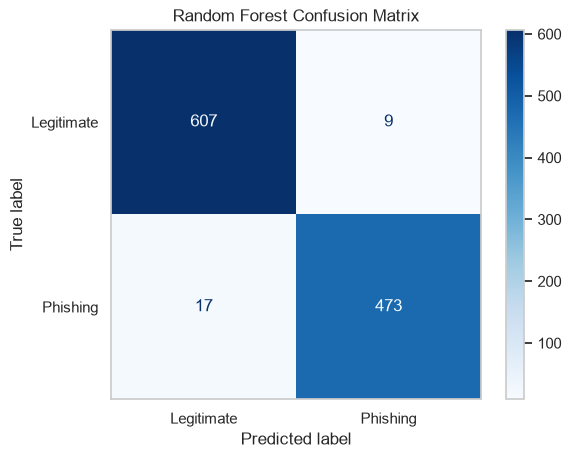

In [13]:
best_model_name = evaluation_results.iloc[0]["Model"]
best_predictions = model_predictions[best_model_name]

print("Best model by F1:", best_model_name)
print(classification_report(y_test, best_predictions, target_names=["Legitimate", "Phishing"]))

plot_confusion_matrix(y_test, best_predictions, f"{best_model_name} Confusion Matrix")

## 14. Deployment-Oriented Metrics: PR-AUC and F2

The reviewer feedback correctly notes that high benchmark accuracy is not enough for cybersecurity deployment. A phishing detector should be evaluated with metrics that focus on the positive class, because the most important operational question is whether phishing sites are caught.

**PR-AUC / Average Precision** is useful because it summarizes precision-recall behavior across thresholds and focuses on phishing as the positive class. This is especially important when future real-world traffic is imbalanced.

**F2-score** gives recall more weight than precision. This is appropriate for phishing detection because a false negative means a phishing site was missed, which can lead to credential theft, fraud, or malware delivery. Precision still matters, because false positives block legitimate sites, but recall is usually the higher-priority security objective.

In [14]:
deployment_metric_columns = [
    "Model",
    "Precision",
    "Recall",
    "F1",
    "F2",
    "ROC-AUC",
    "PR-AUC / Average Precision",
]

deployment_metrics = evaluation_results[deployment_metric_columns].sort_values(
    "PR-AUC / Average Precision",
    ascending=False,
)
display(deployment_metrics)

,Model,Precision,Recall,F1,F2,ROC-AUC,PR-AUC / Average Precision
2,Random Forest,0.981328,0.965306,0.973251,0.968468,0.996520,0.996443
3,XGBoost,0.972917,0.953061,0.962887,0.956967,0.995239,0.994829
0,Logistic Regression,0.936306,0.900000,0.917794,0.907034,0.978164,0.976813
1,Decision Tree,0.979036,0.953061,0.965874,0.958145,0.979216,0.969293


## 15. Precision-Recall Curves

Precision-Recall curves show the trade-off between catching phishing sites and avoiding false alarms. They are more deployment-relevant than accuracy when the positive class is the security event of interest.

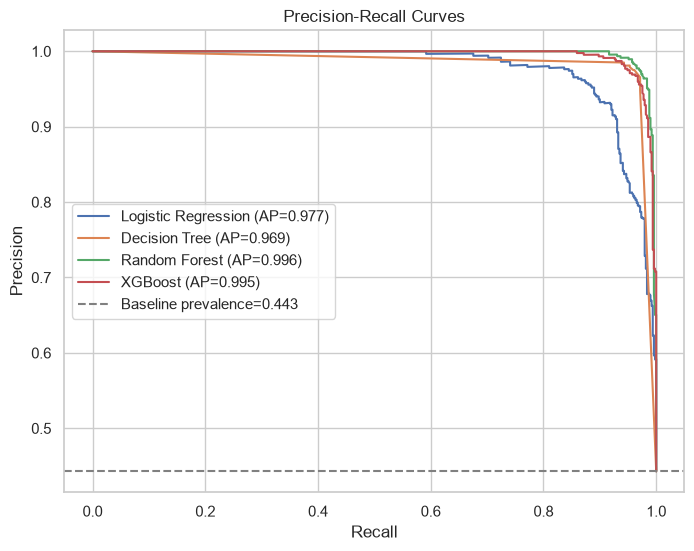

In [15]:
plt.figure(figsize=(8, 6))
for model_name, y_score in model_scores.items():
    precision_values, recall_values, _ = precision_recall_curve(y_test, y_score)
    average_precision = average_precision_score(y_test, y_score)
    plt.plot(
        recall_values,
        precision_values,
        label=f"{model_name} (AP={average_precision:.3f})",
    )

baseline = y_test.mean()
plt.axhline(baseline, color="gray", linestyle="--", label=f"Baseline prevalence={baseline:.3f}")
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

## 16. Threshold Tuning for Cybersecurity Deployment

Most classifiers use a default threshold of `0.50`: predict phishing when the phishing probability is at least 0.50. This default is not necessarily optimal for security deployment.

Lowering the threshold usually increases recall and reduces false negatives, but it also increases false positives. The selected threshold should reflect operational priorities: a warning-only detector can tolerate more false positives than an automatic blocking system.

In [16]:
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
best_scores = model_scores[best_model_name]

threshold_rows = []
for threshold in thresholds:
    threshold_predictions = (best_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_predictions).ravel()
    threshold_rows.append(
        {
            "Model": best_model_name,
            "Threshold": threshold,
            "Precision": precision_score(y_test, threshold_predictions, zero_division=0),
            "Recall": recall_score(y_test, threshold_predictions, zero_division=0),
            "F1": f1_score(y_test, threshold_predictions, zero_division=0),
            "F2": fbeta_score(y_test, threshold_predictions, beta=2, zero_division=0),
            "False Positives": fp,
            "False Negatives": fn,
        }
    )

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results)

default_threshold_row = threshold_results[threshold_results["Threshold"] == 0.50].iloc[0]
reasonable_false_positive_limit = max(50, int(default_threshold_row["False Positives"]) * 4)
candidate_thresholds = threshold_results[
    threshold_results["False Positives"] <= reasonable_false_positive_limit
].copy()

selected_threshold_row = candidate_thresholds.sort_values(
    ["F2", "Recall", "False Positives"],
    ascending=[False, False, True],
).iloc[0]

print("Default threshold row:")
display(default_threshold_row.to_frame().T)
print(f"Reasonable false-positive limit used for this experiment: {reasonable_false_positive_limit}")
print("Selected cybersecurity-aware threshold:")
display(selected_threshold_row.to_frame().T)

,Model,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives
0,Random Forest,0.1,0.879061,0.993878,0.932950,0.968576,67,3
1,Random Forest,0.2,0.932563,0.987755,0.959366,0.976200,35,6
2,Random Forest,0.3,0.954455,0.983673,0.968844,0.977688,23,8
3,Random Forest,0.4,0.973415,0.971429,0.972421,0.971825,13,14
4,Random Forest,0.5,0.981328,0.965306,0.973251,0.968468,9,17
5,Random Forest,0.6,0.985294,0.957143,0.971014,0.962644,7,21
6,Random Forest,0.7,0.991416,0.942857,0.966527,0.952185,4,28
7,Random Forest,0.8,0.995604,0.924490,0.958730,0.937888,2,37
8,Random Forest,0.9,1.000000,0.885714,0.939394,0.906433,0,56


Default threshold row:


,Model,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives
4,Random Forest,0.5,0.981328,0.965306,0.973251,0.968468,9,17


Reasonable false-positive limit used for this experiment: 50
Selected cybersecurity-aware threshold:


,Model,Threshold,Precision,Recall,F1,F2,False Positives,False Negatives
2,Random Forest,0.3,0.954455,0.983673,0.968844,0.977688,23,8


### Threshold Tuning Interpretation

The threshold-tuning experiment tests the reviewer's concern directly: high accuracy at the default threshold does not prove that the model is ready for deployment. A lower threshold may be preferable if it catches more phishing sites and keeps false positives at a manageable level.

In a real organization, this threshold should be chosen with security analysts and business stakeholders. If the model blocks access automatically, false positives are more costly. If the model only generates warnings or analyst triage alerts, a lower threshold may be acceptable because missed phishing sites are more dangerous.

## 17. Deployment-Oriented Critical Evaluation

The dataset is static and may not represent modern phishing tactics. Attackers continuously adapt by using HTTPS, more realistic domains, URL shorteners, compromised legitimate infrastructure, and brand impersonation strategies that may not be captured by older hand-crafted features.

A random train/test split can overestimate performance if similar websites, templates, or feature patterns appear in both training and test data. Real phishing detection requires temporal validation: train on older samples and test on newer attacks.

Accuracy is not sufficient because phishing data may be imbalanced in real traffic. False negatives are dangerous because phishing sites are missed and users may lose credentials or sensitive information. False positives are also costly because legitimate sites may be blocked, causing business disruption and alert fatigue.

Threshold choice should depend on operational security priorities. A model with slightly lower accuracy but higher recall, F2-score, or PR-AUC may be preferable when the security objective is to avoid missed phishing sites.

## 18. Error Analysis

In this notebook, phishing is the positive class:

- **False Positive**: a legitimate website is classified as phishing.
- **False Negative**: a phishing website is classified as legitimate.

False negatives are usually more dangerous because a phishing site can reach the user. False positives are also important because blocking legitimate websites creates operational disruption and alert fatigue.

In [17]:
error_analysis = X_test.copy()
error_analysis["true_label"] = y_test.values
error_analysis["predicted_label"] = best_predictions
error_analysis["error_type"] = np.select(
    [
        (error_analysis["true_label"] == 0) & (error_analysis["predicted_label"] == 1),
        (error_analysis["true_label"] == 1) & (error_analysis["predicted_label"] == 0),
    ],
    ["False Positive: legitimate flagged as phishing", "False Negative: phishing missed"],
    default="Correct",
)

misclassified_examples = error_analysis[error_analysis["error_type"] != "Correct"]

print("Total misclassified examples:", len(misclassified_examples))
display(misclassified_examples["error_type"].value_counts().to_frame("count"))
display(misclassified_examples.head(10))

Total misclassified examples: 26


,count
error_type,
False Negative: phishing missed,17
False Positive: legitimate flagged as phishing,9


,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,true_label,predicted_label,error_type
7158,1,-1,1,1,1,-1,0,1,-1,1,...,-1,1,1,1,1,0,1,1,0,False Negative: phishing missed
9652,1,-1,1,1,1,-1,1,1,-1,1,...,1,1,0,-1,1,0,1,1,0,False Negative: phishing missed
9328,-1,-1,1,1,1,-1,1,-1,1,1,...,1,1,0,-1,1,1,1,0,1,False Positive: legitimate flagged as phishing
8198,-1,-1,1,1,1,-1,-1,-1,-1,1,...,1,1,-1,-1,1,1,1,0,1,False Positive: legitimate flagged as phishing
1676,1,-1,1,1,1,-1,-1,1,-1,1,...,1,-1,0,-1,-1,1,1,1,0,False Negative: phishing missed
8573,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,1,1,0,1,1,0,False Negative: phishing missed
8419,-1,-1,1,1,1,-1,-1,1,-1,1,...,1,1,1,-1,1,1,1,1,0,False Negative: phishing missed
355,1,-1,1,1,1,-1,1,1,-1,-1,...,1,-1,0,-1,1,1,1,1,0,False Negative: phishing missed
9381,1,-1,1,1,1,-1,0,1,1,1,...,1,1,1,-1,1,1,1,1,0,False Negative: phishing missed
9573,1,-1,1,1,1,-1,1,1,-1,1,...,1,1,0,-1,1,-1,1,0,1,False Positive: legitimate flagged as phishing


In [18]:
false_positive_examples = misclassified_examples[
    misclassified_examples["error_type"] == "False Positive: legitimate flagged as phishing"
]
false_negative_examples = misclassified_examples[
    misclassified_examples["error_type"] == "False Negative: phishing missed"
]

print("False positives:", len(false_positive_examples))
display(false_positive_examples.head())

print("False negatives:", len(false_negative_examples))
display(false_negative_examples.head())

if not misclassified_examples.empty:
    error_profile = misclassified_examples.groupby("error_type")[X.columns].mean().T
    display(error_profile.head(20))

False positives: 9


,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,true_label,predicted_label,error_type
9328,-1,-1,1,1,1,-1,1,-1,1,1,...,1,1,0,-1,1,1,1,0,1,False Positive: legitimate flagged as phishing
8198,-1,-1,1,1,1,-1,-1,-1,-1,1,...,1,1,-1,-1,1,1,1,0,1,False Positive: legitimate flagged as phishing
9573,1,-1,1,1,1,-1,1,1,-1,1,...,1,1,0,-1,1,-1,1,0,1,False Positive: legitimate flagged as phishing
5203,1,-1,1,1,1,-1,-1,1,1,1,...,-1,1,1,1,1,0,1,0,1,False Positive: legitimate flagged as phishing
3671,1,-1,1,1,1,-1,0,1,-1,1,...,1,-1,1,-1,1,1,1,0,1,False Positive: legitimate flagged as phishing


False negatives: 17


,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,true_label,predicted_label,error_type
7158,1,-1,1,1,1,-1,0,1,-1,1,...,-1,1,1,1,1,0,1,1,0,False Negative: phishing missed
9652,1,-1,1,1,1,-1,1,1,-1,1,...,1,1,0,-1,1,0,1,1,0,False Negative: phishing missed
1676,1,-1,1,1,1,-1,-1,1,-1,1,...,1,-1,0,-1,-1,1,1,1,0,False Negative: phishing missed
8573,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,1,1,0,1,1,0,False Negative: phishing missed
8419,-1,-1,1,1,1,-1,-1,1,-1,1,...,1,1,1,-1,1,1,1,1,0,False Negative: phishing missed


error_type,False Negative: phishing missed,False Positive: legitimate flagged as phishing
having_IPhaving_IP_Address,0.294118,0.555556
URLURL_Length,-0.764706,-1.000000
Shortining_Service,1.000000,1.000000
having_At_Symbol,0.882353,1.000000
double_slash_redirecting,1.000000,1.000000
Prefix_Suffix,-1.000000,-1.000000
having_Sub_Domain,0.117647,0.000000
SSLfinal_State,0.647059,0.555556
Domain_registeration_length,-0.411765,-0.555556
Favicon,0.764706,1.000000


### Cybersecurity Interpretation of Errors

False positives can block legitimate business activity and reduce user trust in the detector. If a security system generates too many false positives, users may bypass warnings.

False negatives are more severe in phishing detection because the system allows a malicious website to pass as legitimate. These errors may lead to stolen credentials, account takeover, financial fraud, or malware delivery.

A strong phishing detector should therefore balance high recall with acceptable precision, depending on whether it is used for blocking, warning, or analyst triage.

## 19. Feature Importance

Feature importance helps explain model behavior. For tree-based models this uses built-in feature importance. For Logistic Regression it uses the absolute coefficient values.

,importance
SSLfinal_State,0.323756
URL_of_Anchor,0.238644
web_traffic,0.074197
having_Sub_Domain,0.063640
Prefix_Suffix,0.045204
Links_in_tags,0.043150
SFH,0.022260
Request_URL,0.019381
Links_pointing_to_page,0.018823
Domain_registeration_length,0.016875


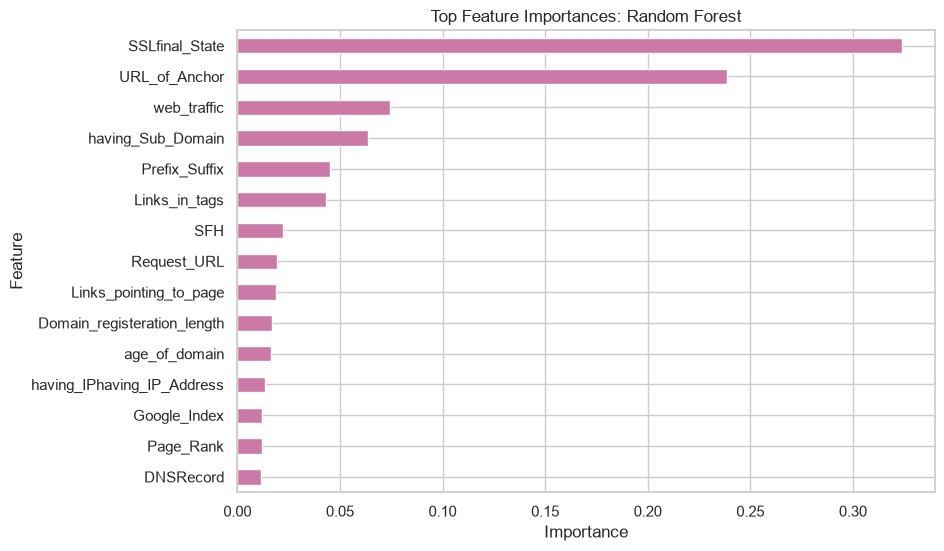

In [19]:
def extract_feature_importance(fitted_model, feature_names):
    model_object = fitted_model
    if isinstance(fitted_model, Pipeline):
        model_object = fitted_model.named_steps["model"]
    if hasattr(model_object, "feature_importances_"):
        return pd.Series(model_object.feature_importances_, index=feature_names).sort_values(ascending=False)
    if hasattr(model_object, "coef_"):
        return pd.Series(np.abs(model_object.coef_[0]), index=feature_names).sort_values(ascending=False)
    return None


feature_importance = extract_feature_importance(fitted_models[best_model_name], X.columns)
if feature_importance is not None:
    display(feature_importance.head(15).to_frame("importance"))
    plt.figure(figsize=(9, 6))
    feature_importance.head(15).sort_values().plot(kind="barh", color="#cc79a7")
    plt.title(f"Top Feature Importances: {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print("Feature importance is not directly available for this model.")

## 20. Reproducibility Analysis

The original repository is valuable because it publishes code and data, but it has several reproducibility issues:

- The dependency file name in the repository is misspelled as `requirment.txt`.
- The README refers to a different misspelled file name.
- Package versions are not pinned.
- The notebooks do not clearly document all environment details.
- Some code is exploratory rather than organized as a final reproducible project.
- The dataset is static and may not represent modern phishing campaigns.

This project improves reproducibility by organizing the dataset locally, using a clean notebook, fixed `random_state=42`, stratified splitting, explicit dependencies, and clear helper functions.

## 21. Conclusions

This reproduction evaluates classical machine-learning models on engineered phishing website features. Strong performance on this dataset can support the paper's main claim that machine learning is useful for phishing detection.

However, cybersecurity deployment requires more than high benchmark accuracy. The model should be tested on newer data, time-based splits, real benign traffic, and adversarially adapted phishing examples.